---
title: "A simple LLM Agent Workflow with LangGraph" 
author: "Peyman Kor"

date: 2025-01-28

categories: [agenticworkflow] 

tags: [langgraph, agentic, workflow]

---

## Introduction to AI Agent



These days there is a lot of discussion about AI agents, and it seems to be becoming a hot topic. Essentially, it's an improvement over the basic LLM agent by adding 1) memory 2) tools and 3) planning capacity, allowing us to get more out of the standalone LLM.

Here's my initial idea:


- The memory can be both short-term (Short-term memory can be the dialog history) or long-term 
- The tools can be API calls, so the LLM can access specific information, for example internet API to get the additional information
- The planning section shows how the LLM can divide multiple tasks and execute them autonomously

In this short blog, I'm going to show what LangGraph is - a well-established and structured Python framework for building LLM agents. 


What we want to do is very simple:

1. We start with one question (a query)
2. That query goes to the LLM tools (Wikipedia and web search)
3. Both tools generate some results
4. We combine those results
5. We give that context to the LLM so it can reply now with the context

Essentially, we are increasing the power of the LLM with additional tools. It's like a chef in the kitchen - if you give them food order, they can cook, but if you give them more tools like a heater or different equipment, they will be much more capable. That's the whole idea of the agent, and we will continue working with that idea.


## Setting up the API keys



So the first thing is that we need to give the API key of the open AI. In order to use the LLM from the OpenAI. So for that one in this case I have `.env` file where the I gave the openai ky is available at that file. So I'm going to load that file and then I'm going to use the openai API key. Alternatively, you can just put the API key directly in the code. I wrote method 2 in the code below. 

In [ ]:
# Method 1
import os
from dotenv import load_dotenv

load_dotenv(override=True)

openai_api_key = os.getenv("OPENAI_API_KEY")


# Method 2
#import os
#os.environ["OPENAI_API_KEY"] = "your-api-key"

## Report with Standalone LLM


Now let's get started. First, we import ChatOpenAI from langchain_openai. I'm using GPT-4-mini since it's the most cost-effective option. My test query is "briefly explain DeepSeek" - I purposefully selected this query to benchmark how the LLM agent improves the response compared to using just the LLM alone. This serves as an evaluation metric. The code uses a simple system message to set up the assistant role, and I save the report from the LLM in a markdown file for better readability.





In [15]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

query = "Briefly explain me DeepSeek and how it affected NVIDIA Share price"

messages = [
    (
        "system",
        "You are a helpful assistant that give me short report about the user question",
    ),
    ("human", query),
]
answer = llm.invoke(messages)

# Save answer content to markdown file
with open("deepseek_report_llm.md", "w") as f:
    f.write("# Report using LLM\n\n")
    f.write(answer.content)


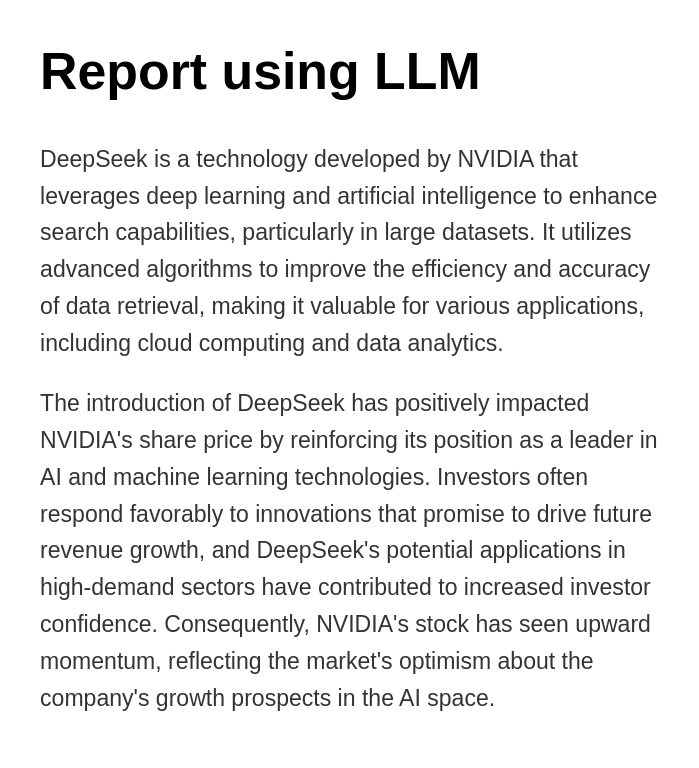


## Agentic Workflow

Now we'll enhance our LLM with additional tools to produce a more informed report (previous report was merely hallucination and not satisfactory). We'll use two main tools:

1. Web search using Tavily
2. Wikipedia search

The workflow is implemented using a `State` class that tracks:
- `question`: The user's original query
- `context`: Combined results from web and Wikipedia searches (which is a list, added together)
- `answer`: The final response generated by the LLM

The State class uses a TypedDict to enforce these three fields. 

In [17]:

from typing import Any
from typing_extensions import TypedDict
from typing import Annotated
import operator

class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]


# You need to get the tavily api key from the tavily website and put it in the .env file
# https://app.tavily.com/
tavily_api_key = os.getenv("TAVILY_API_KEY")

### Define the Tools

Here we have two search functions. In both functions, we take a question from the state (which we defined in the previous section) and pass it to either web search or Wikipedia search. These tools provide additional context to the LLM so it can generate a better informed report.

In [18]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults


def search_web(state):
    
    """ Retrieve docs from web search """

    # Search
    tavily_search = TavilySearchResults(max_results=5)
    search_docs = tavily_search.invoke(state['question'])

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


def search_wikipedia(state):
    
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


## Generate the answer

Now with that context the generate answer function takes that state which has a question and also context that provided from the previous two tools function and now we answer the same question which was about NVIDIA and also from the deep seek with this context. So that's the kind of the bringing the more context to the workflow. 

In [10]:
def generate_answer(state):
    
    """ Node to answer a question """

    # Get state
    context = state["context"]
    question = state["question"]

    # Template
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # Answer
    
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # Append it to state
    return {"answer": answer, "context": context}

## Building the graph

Now we build the graph. We start with the state, and then we add the nodes. We add the search_web and search_wikipedia nodes, and then we add the generate_answer node. We then add the edges, and then we compile the graph. 

Note that in the in the final graph we see that we have a 5 nodes but just the first note is a start and the last note is the end, but those are the default one. But then we only have a 31 which is two of the tools, and then gathering and getting the answer using a tool which is another tools. 


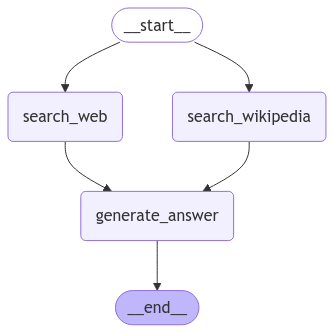

In [19]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(State)


# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Add edges, flow
# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)

from IPython.display import Image, display
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Report with Agent 


Now as you can see, we are asking the same question again about DeepSeek and how it affected the NVIDIA share price. This time we are invoking the graph that we defined earlier, which is a combination of all the edges and nodes that we put together. After compiling the graph in the previous step, it is now ready to function as a workflow. As before, I save the final report as a markdown file for easier readability and comparison.

In [ ]:
result = graph.invoke({"question": 
                       "Briefly explain me DeepSeek and how it affected NVIDIA Share price"})


# Save the answer to a markdown file
with open('deepseek_report_agent.md', 'w') as f:
    f.write("# Report using Agent\n\n")
    f.write(result['answer'].content)

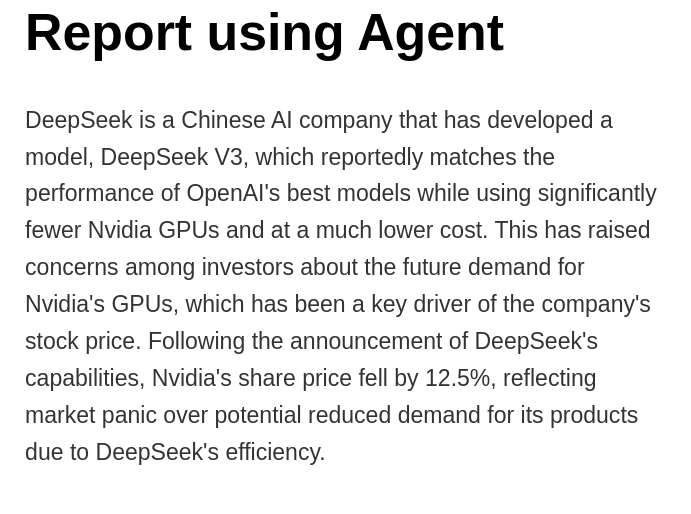
